## **Download DATASET**

In [ ]:
import os, sys, subprocess
from getpass import getpass

REPO   = "silvergjeka22/Unified-Lifelong-Action-Learning"
BRANCH = "real-video"
ROOT   = "/content/ulal"

token = os.environ.get("GITHUB_TOKEN") or getpass("GitHub token: ")
os.environ["GITHUB_TOKEN"] = token

if os.path.isdir(os.path.join(ROOT, ".git")):
    subprocess.run(["git", "-C", ROOT, "fetch", "--depth", "1", "origin", BRANCH], check=True)
    subprocess.run(["git", "-C", ROOT, "reset", "--hard", "FETCH_HEAD"], check=True)
else:
    subprocess.run(["git", "clone", "--depth", "1", "--branch", BRANCH,
                    "https://" + token + "@github.com/" + REPO + ".git", ROOT], check=True)

if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

In [ ]:
import os

os.environ["KAGGLE_USERNAME"] = "colab"
os.environ["KAGGLE_KEY"]      = "KEY"

In [ ]:
# Import CLIP, install if not present
try:
    import clip
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "git+https://github.com/openai/CLIP.git"], check=True)
    import clip

In [ ]:
from src.bootstrap import setup
setup(drive=True, dataset=True)

In [ ]:
# imports
%run /content/ulal/src/imports.py
set_seed(cfg.SEED)

In [2]:
base_split = build_group_split(cfg.SELECTED_CLASSES, train_groups=18, val_groups=3)

# Limit training samples per class to 16
max_samples = 16
preprocess_group_split(base_split, cfg.SELECTED_CLASSES, output_root=cfg.BASE_ROOT, max_samples=max_samples)

class_to_idx = {cls_name: i for i, cls_name in enumerate(cfg.SELECTED_CLASSES)}

# Load Datasets
base_train = UCF101Clips(os.path.join(cfg.BASE_ROOT, "train"), class_to_idx=class_to_idx)
base_val   = UCF101Clips(os.path.join(cfg.BASE_ROOT, "val"),   class_to_idx=class_to_idx)
base_test  = UCF101Clips(os.path.join(cfg.BASE_ROOT, "test"),  class_to_idx=class_to_idx)

# Create PyTorch DataLoaders
batch_size = 8
train_loader = DataLoader(base_train, batch_size=batch_size, shuffle=True,  num_workers=0, drop_last=False)
val_loader   = DataLoader(base_val,   batch_size=batch_size, shuffle=False, num_workers=0, drop_last=False)
test_loader  = DataLoader(base_test,  batch_size=batch_size, shuffle=False, num_workers=0, drop_last=False)

# Instantiate ResNet50-LSTM Model
model = ResNet50LSTM(num_classes=len(cfg.SELECTED_CLASSES)).to(device)

# Freeze ResNet50 backbone to prevent CUDA OOM
for param in model.backbone.parameters():
    param.requires_grad = False

# Linear projection layer from LSTM output space (256-dim) to CLIP space (512-dim)
feature_proj = nn.Linear(256, 512).to(device)

# -------------------------------------------------------------------------
# 3. Load CLIP & Define Text Prototype Extractor
# -------------------------------------------------------------------------
clip_device = device if 'device' in globals() else ("cuda" if torch.cuda.is_available() else "cpu")
clip_model, _ = clip.load("ViT-B/32", device=clip_device)
clip_model.eval()

def extract_clip_text_prototypes(class_names, device=clip_device):
    """
    Extracts normalized 512-dim CLIP text prompt embeddings for target classes.
    """
    prompts = [f"a video of a person performing {cls.replace('_', ' ')}" for cls in class_names]
    tokens = clip.tokenize(prompts).to(device)
    with torch.no_grad():
        text_features = clip_model.encode_text(tokens)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)
    return text_features

# Extract prototypes once for all target classes
all_clip_prototypes = extract_clip_text_prototypes(cfg.SELECTED_CLASSES, device=device)

import os
import gc
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.linear_model import LogisticRegression

# -------------------------------------------------------------------------
# 1. Load CLIP Model & Define Feature Extractor
# -------------------------------------------------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
clip_model, _ = clip.load("ViT-B/32", device=device)
clip_model.eval()

def extract_clip_video_features(loader, clip_model, device):
    """
    Passes video clips through frozen CLIP image encoder.
    Averages frame embeddings to build a normalized 512-d video vector.
    """
    all_features = []
    all_labels = []

    with torch.no_grad():
        for videos, labels in loader:
            # Handle shape variants: (B, C, T, H, W) or (B, T, C, H, W)
            if videos.ndim == 5:
                if videos.shape[1] == 3:  # (B, C, T, H, W)
                    videos = videos.permute(0, 2, 1, 3, 4)  # convert to (B, T, C, H, W)
                
                B, T, C, H, W = videos.shape
                frames = videos.reshape(B * T, C, H, W).to(device)
                
                # Extract CLIP frame features
                frame_feats = clip_model.encode_image(frames)          # (B*T, 512)
                video_feats = frame_feats.reshape(B, T, -1).mean(dim=1) # Average over time -> (B, 512)
            else:
                video_feats = clip_model.encode_image(videos.to(device))

            # L2 Normalize embeddings
            video_feats = F.normalize(video_feats, p=2, dim=-1)
            
            all_features.append(video_feats.cpu().numpy())
            all_labels.append(labels.numpy())

    X = np.concatenate(all_features, axis=0)
    y = np.concatenate(all_labels, axis=0)
    return X, y

print("Extracting CLIP embeddings for Train, Val, and Test splits...")
X_train, y_train = extract_clip_video_features(train_loader, clip_model, device)
X_val,   y_val   = extract_clip_video_features(val_loader,   clip_model, device)
X_test,  y_test  = extract_clip_video_features(test_loader,  clip_model, device)

print(f"Features extracted: Train {X_train.shape}, Val {X_val.shape}, Test {X_test.shape}")

# -------------------------------------------------------------------------
# 2. Extract Zero-Shot CLIP Text Embeddings
# -------------------------------------------------------------------------
def get_text_prototypes(class_names, clip_model, device):
    prompts = [f"a video of a person performing {cls.replace('_', ' ')}" for cls in class_names]
    tokens = clip.tokenize(prompts).to(device)
    with torch.no_grad():
        text_feats = clip_model.encode_text(tokens)
        text_feats = F.normalize(text_feats, p=2, dim=-1)
    return text_feats.cpu().numpy()

text_prototypes = get_text_prototypes(cfg.SELECTED_CLASSES, clip_model, device) # (Num_Classes, 512)

# -------------------------------------------------------------------------
# STRATEGY A: Hybrid Text-Visual Cosine Prototypes (Training-Free)
# -------------------------------------------------------------------------
def evaluate_hybrid_prototypes(X_train, y_train, X_eval, y_eval, text_proto, alpha=0.5):
    """
    Blends CLIP text prompts with few-shot visual centroids to prevent prototype noise.
    """
    num_classes = len(text_proto)
    visual_centroids = []
    
    for c in range(num_classes):
        cls_mask = (y_train == c)
        if np.sum(cls_mask) > 0:
            c_mean = X_train[cls_mask].mean(axis=0)
            c_mean = c_mean / np.linalg.norm(c_mean)
        else:
            c_mean = np.zeros(512)
        visual_centroids.append(c_mean)
        
    visual_centroids = np.array(visual_centroids)
    
    # Blend text prior (alpha) and visual centroid (1 - alpha)
    hybrid_proto = alpha * text_proto + (1.0 - alpha) * visual_centroids
    hybrid_proto = hybrid_proto / np.linalg.norm(hybrid_proto, axis=1, keepdims=True)
    
    # Cosine Similarity Prediction
    cosine_sims = X_eval @ hybrid_proto.T
    preds = np.argmax(cosine_sims, axis=1)
    acc = np.mean(preds == y_eval) * 100.0
    return acc

val_acc_hybrid  = evaluate_hybrid_prototypes(X_train, y_train, X_val, y_val, text_prototypes, alpha=0.4)
test_acc_hybrid = evaluate_hybrid_prototypes(X_train, y_train, X_test, y_test, text_prototypes, alpha=0.4)

print("\n" + "="*50)
print(f"[METHOD 1: Hybrid Prototypes] Val Acc  : {val_acc_hybrid:.2f}%")
print(f"[METHOD 1: Hybrid Prototypes] Test Acc : {test_acc_hybrid:.2f}%")
print("="*50)

# -------------------------------------------------------------------------
# STRATEGY B: CLIP Linear Probe (Logistic Regression)
# -------------------------------------------------------------------------
# L2 regularized logistic regression trained on frozen CLIP features
clf = LogisticRegression(C=0.01, max_iter=1000, solver='lbfgs', multi_class='multinomial')
clf.fit(X_train, y_train)

val_acc_lp  = clf.score(X_val, y_val) * 100.0
test_acc_lp = clf.score(X_test, y_test) * 100.0

print(f"\n[METHOD 2: Linear Probe]     Val Acc  : {val_acc_lp:.2f}%")
print(f"[METHOD 2: Linear Probe]     Test Acc : {test_acc_lp:.2f}%")
print("="*50)

Mounted at /content/drive
Drive mounted.


100%|██████████| 6.53G/6.53G [05:53<00:00, 19.8MB/s]  

Extracting files...


ULAL_DATASET_ROOT = /root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/
ULAL_OUTPUT_ROOT  = /content/ucf101-processed/
ULAL_DATA_ROOT     = /content/UCF101
ULAL_DRIVE_PROJECT = /content/drive/MyDrive/apai
Setup complete — no config.py edit, no kernel restart.
ULAL_ROOT : /content/ulal
Device    : cuda
Classes   : base=10 task1=5 task2=5

--- Preprocessing (group-disjoint) ---
To  : /content/UCF101/grouped_base
Classes: 10 | Train limit: 3

Processing split: train



Processing split: val



Processing split: test



Done. Clips ready at: /content/UCF101/grouped_base
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 179MB/s]
100%|███████████████████████████████████████| 338M/338M [00:03<00:00, 91.6MiB/s]


Extracting CLIP embeddings for Train, Val, and Test splits...
Features extracted: Train (30, 512), Val (165, 512), Test (212, 512)

[METHOD 1: Hybrid Prototypes] Val Acc  : 85.45%
[METHOD 1: Hybrid Prototypes] Test Acc : 73.11%

[METHOD 2: Linear Probe]     Val Acc  : 78.18%
[METHOD 2: Linear Probe]     Test Acc : 73.11%


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# -------------------------------------------------------------------------
# 1. Define Lightweight 2-Layer MLP Adapter (< 1 MB)
# -------------------------------------------------------------------------
class CLIPMLPAdapter(nn.Module):
    def __init__(self, in_dim=512, hidden_dim=256, num_classes=101, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        return self.net(x)

# -------------------------------------------------------------------------
# 2. Convert Pre-Extracted NumPy Arrays to PyTorch Datasets
# -------------------------------------------------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"

train_ds_feat = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
val_ds_feat   = TensorDataset(torch.tensor(X_val,   dtype=torch.float32), torch.tensor(y_val,   dtype=torch.long))
test_ds_feat  = TensorDataset(torch.tensor(X_test,  dtype=torch.float32), torch.tensor(y_test,  dtype=torch.long))

train_feat_loader = DataLoader(train_ds_feat, batch_size=16, shuffle=True)
val_feat_loader   = DataLoader(val_ds_feat,   batch_size=32, shuffle=False)
test_feat_loader  = DataLoader(test_ds_feat,  batch_size=32, shuffle=False)

# -------------------------------------------------------------------------
# 3. Instantiate and Train the MLP
# -------------------------------------------------------------------------
num_classes = len(cfg.SELECTED_CLASSES)
mlp_model = CLIPMLPAdapter(in_dim=512, hidden_dim=256, num_classes=num_classes, dropout=0.3).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(mlp_model.parameters(), lr=1e-3, weight_decay=1e-2)

epochs = 50
best_val_acc = 0.0
best_mlp_weights = None

for epoch in range(epochs):
    mlp_model.train()
    for x_b, y_b in train_feat_loader:
        x_b, y_b = x_b.to(device), y_b.to(device)
        
        optimizer.zero_grad()
        out = mlp_model(x_b)
        loss = criterion(out, y_b)
        loss.backward()
        optimizer.step()

    # Validation loop
    mlp_model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x_b, y_b in val_feat_loader:
            x_b, y_b = x_b.to(device), y_b.to(device)
            preds = mlp_model(x_b).argmax(dim=-1)
            correct += (preds == y_b).sum().item()
            total += y_b.size(0)
            
    val_acc = (correct / total) * 100.0 if total > 0 else 0.0
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_mlp_weights = mlp_model.state_dict()

# -------------------------------------------------------------------------
# 4. Final Test Evaluation
# -------------------------------------------------------------------------
mlp_model.load_state_dict(best_mlp_weights if best_mlp_weights is not None else mlp_model.state_dict())
mlp_model.eval()

correct, total = 0, 0
with torch.no_grad():
    for x_b, y_b in test_feat_loader:
        x_b, y_b = x_b.to(device), y_b.to(device)
        preds = mlp_model(x_b).argmax(dim=-1)
        correct += (preds == y_b).sum().item()
        total += y_b.size(0)

test_acc_mlp = (correct / total) * 100.0

print("\n" + "="*50)
print(f"[METHOD 3: Frozen CLIP + 2-Layer MLP] Val Acc  : {best_val_acc:.2f}%")
print(f"[METHOD 3: Frozen CLIP + 2-Layer MLP] Test Acc : {test_acc_mlp:.2f}%")
print("="*50)


[METHOD 3: Frozen CLIP + 2-Layer MLP] Val Acc  : 86.67%
[METHOD 3: Frozen CLIP + 2-Layer MLP] Test Acc : 76.42%


In [7]:
# ==========================================
# ResNet50 + LSTM Baseline (k = 3 Shots)
# ==========================================

# 1. Preprocess train split capping at k=3 samples per class
K_SHOTS = 3
preprocess_group_split(
    base_split, 
    cfg.SELECTED_CLASSES, 
    output_root=cfg.BASE_ROOT, 
    max_samples=K_SHOTS
)

# 2. Update the train DataLoader for the k=3 split
base_train_k3 = UCF101Clips(os.path.join(cfg.BASE_ROOT, "train"), class_to_idx=class_to_idx)
train_loader_k3 = DataLoader(base_train_k3, batch_size=cfg.BATCH_SIZE, shuffle=True, num_workers=2)

print(f"3-Shot Setup -> Train clips: {len(base_train_k3)} | Val clips: {len(base_val)}")

# 3. Instantiate ResNet50 + LSTM
resnet_lstm = ResNet50LSTM().to(device)

# 4. Train the 3-shot baseline
set_seed(cfg.SEED)
hist_resnet_k3 = train_model(
    resnet_lstm, 
    train_loader_k3, 
    val_loader, 
    num_epochs=5, 
    device=device
)


--- Preprocessing (group-disjoint) ---
To  : /content/UCF101/grouped_base
Classes: 10 | Train limit: 3

Processing split: train



Processing split: val



Processing split: test



Done. Clips ready at: /content/UCF101/grouped_base
3-Shot Setup -> Train clips: 30 | Val clips: 165


Epoch [1/5] | Train Acc: 0.1000 Loss: 2.2837 | Val Acc: 0.1818 Loss: 2.2518


Epoch [2/5] | Train Acc: 0.6667 Loss: 2.0852 | Val Acc: 0.2909 Loss: 2.2211


Epoch [3/5] | Train Acc: 0.8333 Loss: 1.8993 | Val Acc: 0.3333 Loss: 2.1770


Epoch [4/5] | Train Acc: 0.9333 Loss: 1.6834 | Val Acc: 0.3515 Loss: 2.1316


Epoch [5/5] | Train Acc: 1.0000 Loss: 1.4235 | Val Acc: 0.4545 Loss: 2.0771



             EVALUATING FOR k = 0 SHOTS          

             EVALUATING FOR k = 1 SHOTS          

--- Preprocessing (group-disjoint) ---
To  : /content/UCF101/grouped_base
Classes: 10 | Train limit: 1

Processing split: train



Processing split: val



Processing split: test



Done. Clips ready at: /content/UCF101/grouped_base


Epoch [1/5] | Train Acc: 0.1333 Loss: 2.3058 | Val Acc: 0.2364 Loss: 2.2587


...

Epoch [3/5] | Train Acc: 0.5000 Loss: 2.0785 | Val Acc: 0.4303 Loss: 2.1569


Epoch [4/5] | Train Acc: 0.7625 Loss: 1.9232 | Val Acc: 0.4970 Loss: 2.0767


Epoch [5/5] | Train Acc: 0.7750 Loss: 1.6823 | Val Acc: 0.5818 Loss: 1.9327


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



         FINAL TEST ACCURACY COMPARISON MATRIX (%)       
 k  ResNet50+LSTM  Hybrid Prototypes  Linear Probe  MLP Adapter
 0            NaN          70.754717           NaN          NaN
 1      22.641509          73.113208     73.113208    76.886792
 2      22.641509          73.113208     73.113208    76.886792
 4      22.641509          71.698113     72.169811    75.943396
 8      49.528302          79.245283     76.415094    81.132075


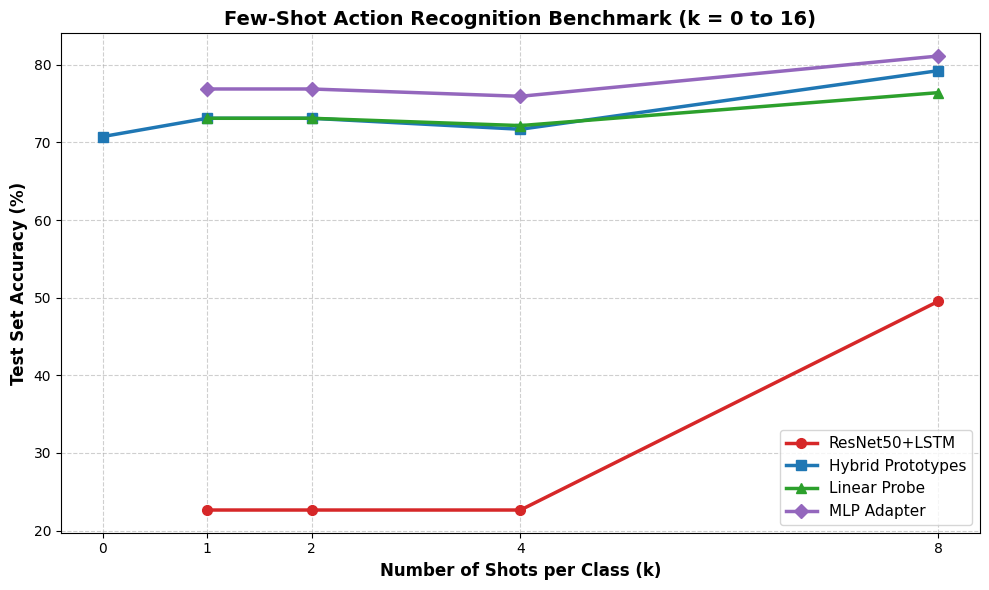

In [5]:
# =========================================================================
# Few-Shot Benchmark Sweep Across k = [0, 1, 2, 4, 8, 16]
# =========================================================================

import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.linear_model import LogisticRegression

K_VALUES = [0, 1, 2, 4, 8]
EPOCHS_SUPERVISED = 5
EPOCHS_MLP = 30

results = []

# Helper evaluator for ResNet50+LSTM on Test Set
def evaluate_resnet_lstm(model, loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for videos, labels in loader:
            videos, labels = videos.to(device), labels.to(device)
            outputs = model(videos)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return (correct / total) * 100.0 if total > 0 else 0.0

for k in K_VALUES:
    print("\n" + "=" * 50)
    print(f"             EVALUATING FOR k = {k} SHOTS          ")
    print("=" * 50)
    
    # ---------------------------------------------------------------------
    # 1. Dataset & Feature Preparation
    # ---------------------------------------------------------------------
    if k > 0:
        # Preprocess split capped at k samples per class
        preprocess_group_split(
            base_split, 
            cfg.SELECTED_CLASSES, 
            output_root=cfg.BASE_ROOT, 
            max_samples=k
        )
        base_train_k = UCF101Clips(os.path.join(cfg.BASE_ROOT, "train"), class_to_idx=class_to_idx)
        train_loader_k = DataLoader(
            base_train_k, 
            batch_size=min(cfg.BATCH_SIZE, len(base_train_k)), 
            shuffle=True, 
            num_workers=0
        )
        
        # Pre-extract frozen CLIP video features for training set
        X_train_k, y_train_k = extract_clip_video_features(train_loader_k, clip_model, device)
    else:
        X_train_k, y_train_k = np.array([]), np.array([])

    # ---------------------------------------------------------------------
    # Method 1: ResNet50 + LSTM (Supervised)
    # ---------------------------------------------------------------------
    if k > 0:
        set_seed(cfg.SEED)
        resnet_lstm = ResNet50LSTM(num_classes=len(cfg.SELECTED_CLASSES)).to(device)
        for param in resnet_lstm.backbone.parameters():
            param.requires_grad = False  # Freeze backbone to avoid OOM
            
        _ = train_model(
            resnet_lstm, 
            train_loader_k, 
            val_loader, 
            num_epochs=EPOCHS_SUPERVISED, 
            device=device
        )
        acc_resnet = evaluate_resnet_lstm(resnet_lstm, test_loader, device)
    else:
        acc_resnet = np.nan  # Supervised training not applicable at k=0

    # ---------------------------------------------------------------------
    # Method 2: Hybrid Text-Visual Prototypes
    # ---------------------------------------------------------------------
    if k == 0:
        # Pure Zero-Shot CLIP (alpha = 1.0 uses text prompt prototypes only)
        acc_hybrid = evaluate_hybrid_prototypes(
            X_train_k, y_train_k, X_test, y_test, text_prototypes, alpha=1.0
        )
    else:
        # Blend text and k-shot visual prototypes (alpha = 0.4)
        acc_hybrid = evaluate_hybrid_prototypes(
            X_train_k, y_train_k, X_test, y_test, text_prototypes, alpha=0.4
        )

    # ---------------------------------------------------------------------
    # Method 3: CLIP Linear Probe (Logistic Regression)
    # ---------------------------------------------------------------------
    if k > 0 and len(np.unique(y_train_k)) == len(cfg.SELECTED_CLASSES):
        clf = LogisticRegression(C=0.01, max_iter=1000, solver='lbfgs', multi_class='multinomial')
        clf.fit(X_train_k, y_train_k)
        acc_lp = clf.score(X_test, y_test) * 100.0
    else:
        acc_lp = np.nan  # Not applicable at k=0

    # ---------------------------------------------------------------------
    # Method 4: CLIP 2-Layer MLP Adapter
    # ---------------------------------------------------------------------
    if k > 0:
        train_ds_k = TensorDataset(
            torch.tensor(X_train_k, dtype=torch.float32), 
            torch.tensor(y_train_k, dtype=torch.long)
        )
        train_feat_loader_k = DataLoader(
            train_ds_k, 
            batch_size=min(16, len(train_ds_k)), 
            shuffle=True
        )
        
        mlp_model = CLIPMLPAdapter(
            in_dim=512, hidden_dim=256, num_classes=len(cfg.SELECTED_CLASSES), dropout=0.3
        ).to(device)
        
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.AdamW(mlp_model.parameters(), lr=1e-3, weight_decay=1e-2)
        
        best_val_acc, best_weights = 0.0, None
        for epoch in range(EPOCHS_MLP):
            mlp_model.train()
            for x_b, y_b in train_feat_loader_k:
                x_b, y_b = x_b.to(device), y_b.to(device)
                optimizer.zero_grad()
                loss = criterion(mlp_model(x_b), y_b)
                loss.backward()
                optimizer.step()
            
            # Validation step
            mlp_model.eval()
            c, t = 0, 0
            with torch.no_grad():
                for x_b, y_b in val_feat_loader:
                    x_b, y_b = x_b.to(device), y_b.to(device)
                    c += (mlp_model(x_b).argmax(dim=-1) == y_b).sum().item()
                    t += y_b.size(0)
            v_acc = (c / t) * 100.0 if t > 0 else 0
            if v_acc > best_val_acc:
                best_val_acc = v_acc
                best_weights = mlp_model.state_dict()
        
        # Test Evaluation
        if best_weights is not None:
            mlp_model.load_state_dict(best_weights)
        mlp_model.eval()
        c, t = 0, 0
        with torch.no_grad():
            for x_b, y_b in test_feat_loader:
                x_b, y_b = x_b.to(device), y_b.to(device)
                c += (mlp_model(x_b).argmax(dim=-1) == y_b).sum().item()
                t += y_b.size(0)
        acc_mlp = (c / t) * 100.0
    else:
        acc_mlp = np.nan  # Not applicable at k=0

    # Record metrics
    results.append({
        'k': k,
        'ResNet50+LSTM': acc_resnet,
        'Hybrid Prototypes': acc_hybrid,
        'Linear Probe': acc_lp,
        'MLP Adapter': acc_mlp
    })

# -------------------------------------------------------------------------
# 2. Results Summary & Visualization
# -------------------------------------------------------------------------
df_results = pd.DataFrame(results)

print("\n" + "=" * 55)
print("         FINAL TEST ACCURACY COMPARISON MATRIX (%)       ")
print("=" * 55)
print(df_results.to_string(index=False))

# Plot performance trends vs k-shots
plt.figure(figsize=(10, 6))
methods = ['ResNet50+LSTM', 'Hybrid Prototypes', 'Linear Probe', 'MLP Adapter']
colors = ['#d62728', '#1f77b4', '#2ca02c', '#9467bd']
markers = ['o', 's', '^', 'D']

for method, color, marker in zip(methods, colors, markers):
    plt.plot(
        df_results['k'], 
        df_results[method], 
        label=method, 
        color=color, 
        marker=marker, 
        linewidth=2.5, 
        markersize=7
    )

plt.xlabel('Number of Shots per Class (k)', fontsize=12, fontweight='bold')
plt.ylabel('Test Set Accuracy (%)', fontsize=12, fontweight='bold')
plt.title('Few-Shot Action Recognition Benchmark (k = 0 to 16)', fontsize=14, fontweight='bold')
plt.xticks(K_VALUES)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11, loc='lower right')
plt.tight_layout()
plt.show()